In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# model = AutoModelForCausalLM.from_pretrained(
#     "Qwen/Qwen2.5-1.5B-Instruct"
# )

# tokenizer = AutoTokenizer.from_pretrained(
#     "Qwen/Qwen2.5-1.5B-Instruct"
# )

Suppose:

* Vocabulary size = 50,000
* Hidden size = 2048

How many trainable parameters does the embedding layer have?

Can you calculate it?

    vocabulary_size × hidden_size ==> 50,000×2,048=102,400,000

    102.4 million trainable parameters

* Suppose you're using a 7B parameter model.
* The embedding layer alone might account for: 102 Million parameters
* That's roughly 1.5% of the entire model.
* Everything else (attention layers, MLPs, etc.) makes up the remaining billions of parameters.


| Topic                              | Status       | Comments                                                                                                      |
| ---------------------------------- | ------------ | ------------------------------------------------------------------------------------------------------------- |
| 🤗 Hugging Face model architecture | 🟡 Partially | We discussed `AutoModelForCausalLM` and `AutoTokenizer`, but we haven't explored the actual model object yet. |
| Tokenizer                          | ✅ Covered    | What it is, why it's needed, encoding and decoding.                                                           |
| Tokens & Token IDs                 | ✅ Covered    | Including subword tokenization and vocabulary.                                                                |
| Attention Mask                     | ✅ Covered    | Including padding and why it's required.                                                                      |
| Model Input                        | 🟡 Partially | We discussed `input_ids` and `attention_mask`, but haven't seen a real Hugging Face input dictionary.         |
| Text Generation                    | 🟡 Partially | Conceptually covered (next-token prediction), but not with actual code.                                       |
| Google Colab setup                 | ❌ Not yet    | Still pending.                                                                                                |


                  User Prompt
                        │
                        ▼
                  Tokenizer
                        │
                        ▼
                  Tokens
                        │
                        ▼
                  Token IDs
                        │
                        ▼
                  Embedding Layer
                        │
                        ▼
                  Transformer Blocks
                        │
                        ▼
                  LM Head
                        │
                        ▼
                  Logits - > Think of logits as raw scores for every token in             the vocabulary.
                        │
                        ▼
                  Softmax - > Softmax converts logits into probabilities. 
                                    (Now the probabilities sum to 0-1)
                        │
                        ▼
                  Sampling / Greedy Selection
                        │
                        ▼
                  Next Token
                        │
                        ▼
                  Repeat...
                        │
                        ▼
                  Tokenizer.decode()
                        │
                        ▼
                  Final Response

these models are called autoregressive—they generate one token at a time, using previously generated tokens as context.

#### Attention:

##### Self - Attention - Each token attends to all tokens in the sequence.

* Example: I love python
* When processing Python, the model doesn't just look at "Python".
* It looks at:

        I

        love

        Python
* and decides how much each token matters.

| Token  | Importance |
| ------ | ---------: |
| I      |       0.10 |
| love   |       0.75 |
| Python |       0.15 |


##### In transformers, every token creates three vectors

* Embedding --> Query(Q), Key(K), Value(V)
* I --> Q1, K1, V1
* love --> Q2, K2, V2
* Python --> Q3, K3, V3

1) Query: Who is related to me?

* Which other tokens should I pay attention to in order to better understand myself?

2) Key: What am I

* Imagine every token wears a badge.

        I
        Key: "I am the subject."

        love
        Key: "I express an action."

        Python
        Key: "I am a programming language."

* The Query from Python compares itself against everyone's Key.

        Python's Query
                │
                ▼
        Compare with Key(I)

        Compare with Key(love)

        Compare with Key(Python)

* The better the match, the higher the attention score.

3) Value: The information I can contribute if someone pays attention to me.

* suppose the model decides

        love     → Very relevant

        Python   → Somewhat relevant

        I         → Slightly relevant


#### Math break down

    I
    [1, 2, 0, 1]

    love
    [0, 3, 1, 2]

    Python
    [2, 1, 3, 0]

* The transformer doesn't use these embeddings directly.
* Instead, it learns three matrices:

        Wq, Wk, Wv

* It computes:

    Q = X × Wq

    K = X × Wk

    V = X × Wv

    where:

        X = embedding matrix
        Wq = Query projection
        Wk = Key projection
        Wv = Value projection

##### Which vectors are actually compared to produce the attention scores?

* Query × Key

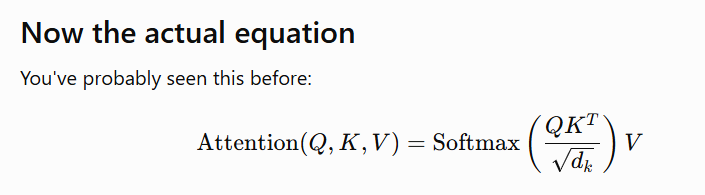


##### Logits - Raw square based on martix multiplication - [2.1, 0.5, 0.3, 0.2, 0.1]
##### Softmax - Softmax converts Logits into probabilities - [0.63, 0.12, 0.10, 0.08, 0.07]

##### Multi head

* Eg: "Apple released a new iPhone in California."
* If we had only one attention head, it might focus on: iPhone  ←→ Apple
* But another relationship exists: Apple  ←→ California (company ↔ location)
* Another: released  ←→ iPhone (action ↔ object)
* So the Transformer says: Let's have multiple attention heads.

Imagine 4 specialists:

* Head 1: Focuses on grammar.
* Head 2: Focuses on semantic meaning.
* Head 3: Focuses on entities (people, places, companies).
* Head 4: Focuses on long-range dependencies.

* Each head learns its own Q, K, and V projections.